<a href="https://colab.research.google.com/github/SadeqAsghari/ALPR_System/blob/main/CRNN_OCR_UPDATE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
Robust CRNN for Multi-Layout Plates

Features:
1. "Split-and-Stitch" Logic: Automatically converts 2-row plates into
   1-row strips to prevent vertical feature collapse.
2. Backbone: Uses MobileNetV3-Small (Pretrained) for high
   Edge/CPU performance on Raspberry Pi CM4.
3. Added Automatic Mixed Precision (AMP) for faster training.
4. Careful Label Parsing: regex stripping to safely ignore duplicate
   file markers (e.g., "_2", "_3") without corrupting the CTC label.
"""

# Dependencies

!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q onnx onnxruntime onnxsim
!pip install -q albumentations editdistance tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import numpy as np
import os
from pathlib import Path
from torch.utils.data import Dataset, DataLoader


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 78.7 MB/s eta 0:00:00


In [2]:
#Configuration & Charset

from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = "/content/drive/MyDrive/italian_plates"
IMG_HEIGHT = 48
IMG_WIDTH = 320  # Wide enough to hold a "stitched" 2-row plate

# VOCABULARY
CHARS = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"
BLANK_TOKEN = '-'
char_to_idx = {c: i + 1 for i, c in enumerate(CHARS)}
char_to_idx[BLANK_TOKEN] = 0
idx_to_char = {i: c for c, i in char_to_idx.items()}
NUM_CLASSES = len(CHARS) + 1


Mounted at /content/drive


In [3]:
#Robust Dataset with "Split-and-Stitch" logic

import albumentations as A
from albumentations.pytorch import ToTensorV2
import re

class RobustPlateDataset(Dataset):
    def __init__(self, dataset_path, is_training=True):
        self.image_paths = list(Path(dataset_path).glob("*.*"))
        self.is_training = is_training

        # Valid extensions
        self.image_paths = [p for p in self.image_paths if p.suffix.lower() in ['.jpg', '.png', '.jpeg']]

        self.transform = A.Compose([
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, p=0.4),
            A.GaussNoise(p=0.2),
            A.Rotate(limit=3, border_mode=cv2.BORDER_CONSTANT, p=0.3),
        ]) if is_training else None

        self.normalize = A.Compose([
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])

    def parse_label(self, filename):
        stem = Path(filename).stem.upper()

        # Remove duplicate suffix (e.g., "_2", "_3") at the end of the filename
        stem = re.sub(r'_\d+$', '', stem)

        # Proceed with standard cleaning (removing 2-row separators)
        clean = stem.replace('_', '')
        return ''.join(c for c in clean if c in CHARS)

    def linearize_2row_plate(self, img):
        h, w = img.shape[:2]
        aspect_ratio = w / h

        if aspect_ratio < 2.5:
            mid_h = h // 2
            top_half = img[0:mid_h, :]

            # Forces bottom_half to be exactly 'mid_h' tall
            # This discards the 1 extra row of pixels if the original image height was an odd number.
            bottom_half = img[mid_h:mid_h*2, :]

            sep = np.zeros((mid_h, 5, 3), dtype=np.uint8)
            stitched = np.hstack([top_half, sep, bottom_half])
            return stitched

        return img

    def resize_pad(self, img):
        h, w = img.shape[:2]
        scale = IMG_HEIGHT / h
        new_w = int(w * scale)

        img = cv2.resize(img, (new_w, IMG_HEIGHT))

        # Pad width if necessary, or crop if too long
        final_img = np.zeros((IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.uint8)
        valid_w = min(new_w, IMG_WIDTH)
        final_img[:, :valid_w, :] = img[:, :valid_w, :]

        return final_img, valid_w

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = cv2.imread(str(path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 1. Linearize 2-row plates
        img = self.linearize_2row_plate(img)

        # 2. Augment
        if self.transform:
            img = self.transform(image=img)['image']

        # 3. Resize & Pad
        img, actual_w = self.resize_pad(img)

        # 4. Normalize
        img = self.normalize(image=img)['image']

        # 5. Label
        label_str = self.parse_label(path.name)
        label = [char_to_idx[c] for c in label_str]
        label_len = len(label)

        # Pad label
        padded_label = label + [0] * (12 - label_len) # Max 12 chars

        return {
            'image': img,
            'label': torch.tensor(padded_label, dtype=torch.long),
            'input_len': torch.tensor(IMG_WIDTH // 8), # MobileNetV3 stride is ~8
            'label_len': torch.tensor(label_len, dtype=torch.long)
        }

In [4]:
# MobileNetV3-CRNN Model

import torchvision.models as models

class MobileNetCRNN(nn.Module):
    def __init__(self, num_classes, hidden_size=256):
        super().__init__()

        # Load MobileNetV3 Small (Suitable for Edge devices)
        weights = models.MobileNet_V3_Small_Weights.DEFAULT
        mobilenet = models.mobilenet_v3_small(weights=weights)

        # Remove classification head, keep features
        # Stride info: MBV3 Small reduces dimensionality by 16x by default.
        # We need to tweak the first layer to retain resolution for small plates.
        self.features = mobilenet.features

        # Modify first stride to keep more spatial info (Stride 2 -> 1)
        self.features[0][0].stride = (1, 1)

        # Output channels of MBV3-Small features is 576
        self.rnn = nn.LSTM(576, hidden_size, bidirectional=True, batch_first=True, num_layers=2)
        self.head = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # x: [B, 3, 48, 320]
        x = self.features(x) # [B, 576, 3, 40] approx (depending on pooling)

        # Collapse Height (Avg Pool vertical axis only)
        x = x.mean(dim=2) # [B, 576, Width]

        # Prepare for RNN
        x = x.permute(0, 2, 1) # [B, Width, 576]

        x, _ = self.rnn(x)
        x = self.head(x)

        return x.permute(1, 0, 2) # [Time, Batch, Class] for CTC Loss

model = MobileNetCRNN(NUM_CLASSES).cuda()
print(f"Model Parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")



Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 146MB/s]


Model Parameters: 4.23M


In [5]:
!pip install tqdm

In [7]:
# Training

from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import editdistance  # Levenshtein distance for CER

# Setup Data
full_dataset = RobustPlateDataset(DATASET_PATH, is_training=True)
train_idx, val_idx = train_test_split(range(len(full_dataset)), test_size=0.1)
train_set = torch.utils.data.Subset(full_dataset, train_idx)
val_set = torch.utils.data.Subset(RobustPlateDataset(DATASET_PATH, is_training=False), val_idx)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)

# Hyperparameters
EPOCHS = 150
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.CTCLoss(blank=0, zero_infinity=True)
scaler = torch.amp.GradScaler('cuda')

# Cosine Annealing Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

def decode(preds):
    pred_indices = preds.argmax(dim=2).detach().cpu().numpy()
    results = []
    for batch_idx in range(pred_indices.shape[1]):
        line = pred_indices[:, batch_idx]
        res = []
        prev = 0
        for p in line:
            if p != prev and p != 0:
                res.append(idx_to_char[p])
            prev = p
        results.append("".join(res))
    return results

print("Starting Training...")

best_acc = 0.0  # Track best accuracy for checkpointing
save_dir = "/content/drive/MyDrive/CRNN_OCR_UPDATE/ocr"
os.makedirs(save_dir, exist_ok=True)

for epoch in range(EPOCHS):
    model.train()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for batch in pbar:
        imgs = batch['image'].cuda()
        labels = batch['label'].cuda()
        label_len = batch['label_len'].cuda()

        curr_bs = imgs.size(0)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            preds = model(imgs)
            actual_T = preds.size(0)
            curr_input_len = torch.full((curr_bs,), actual_T, dtype=torch.long).cuda()
            loss = criterion(preds.log_softmax(2), labels, curr_input_len, label_len)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Display current LR and Loss
        current_lr = scheduler.get_last_lr()[0]
        pbar.set_postfix({'Loss': f"{loss.item():.4f}", 'LR': f"{current_lr:.6f}"})

    # Step the scheduler at the end of the epoch
    scheduler.step()

    # Validation Phase
    model.eval()
    total_acc = 0
    total_cer = 0.0
    total_samples = 0

    with torch.no_grad():
        for batch in val_loader:
            imgs = batch['image'].cuda()
            targets = batch['label']

            preds = model(imgs)
            decoded_preds = decode(preds)

            for i, txt in enumerate(decoded_preds):
                gt_idxs = targets[i].tolist()
                gt_str = "".join([idx_to_char[x] for x in gt_idxs if x != 0])

                # 1. Exact Match Accuracy
                if txt == gt_str:
                    total_acc += 1

                # 2. Character Error Rate (CER)
                if len(gt_str) > 0:
                    cer = editdistance.eval(txt, gt_str) / len(gt_str)
                    total_cer += cer

            total_samples += len(imgs)

    epoch_acc = total_acc / total_samples
    epoch_cer = total_cer / total_samples

    print(f"Epoch {epoch+1} Results -> Exact Acc: {epoch_acc:.2%} | CER: {epoch_cer:.4f}")

    # Save-on-Best Checkpointing
    if epoch_acc > best_acc:
        best_acc = epoch_acc
        print(f" New Best Model! Saving checkpoint (Accuracy: {best_acc:.2%})")
        torch.save(model.state_dict(), f"{save_dir}/mobilenet_crnn_best.pt")

print(f"\n Training Complete. Best Validation Accuracy: {best_acc:.2%}")

Starting Training...


Epoch 1/150:   0%|          | 0/55 [00:00<?, ?it/s]

Epoch 1 Results -> Exact Acc: 91.56% | CER: 0.0126
 New Best Model! Saving checkpoint (Accuracy: 91.56%)


Epoch 2/150:   0%|          | 0/55 [00:00<?, ?it/s]

Epoch 2 Results -> Exact Acc: 95.65% | CER: 0.0080
 New Best Model! Saving checkpoint (Accuracy: 95.65%)


...

Epoch 148 Results -> Exact Acc: 96.93% | CER: 0.0058


Epoch 149/150:   0%|          | 0/55 [00:00<?, ?it/s]

Epoch 149 Results -> Exact Acc: 96.93% | CER: 0.0058


Epoch 150/150:   0%|          | 0/55 [00:00<?, ?it/s]

Epoch 150 Results -> Exact Acc: 97.19% | CER: 0.0055

 Training Complete. Best Validation Accuracy: 97.70%


In [8]:
import torch

# Initialize a fresh model structure
eval_model = MobileNetCRNN(NUM_CLASSES).cuda()

# Load the saved weights from Google Drive
save_path = "/content/drive/MyDrive/CRNN_OCR_UPDATE/ocr/mobilenet_crnn_best.pt"
eval_model.load_state_dict(torch.load(save_path))
eval_model.eval()

print("Model loaded successfully. Running final evaluation...")

total_acc = 0
total_samples = 0

with torch.no_grad():
    for batch in val_loader:
        imgs = batch['image'].cuda()
        targets = batch['label']

        preds = eval_model(imgs)
        decoded_preds = decode(preds)

        # Check accuracy
        for i, txt in enumerate(decoded_preds):
            gt_idxs = targets[i].tolist()
            gt_str = "".join([idx_to_char[x] for x in gt_idxs if x != 0])

            if txt == gt_str:
                total_acc += 1

        total_samples += len(imgs)

final_accuracy = total_acc / total_samples

print(f" FINAL SAVED MODEL ACCURACY: {final_accuracy:.2%}")


Model loaded successfully. Running final evaluation...
 FINAL SAVED MODEL ACCURACY: 97.70%


Loading best model weights...
Running Inference...


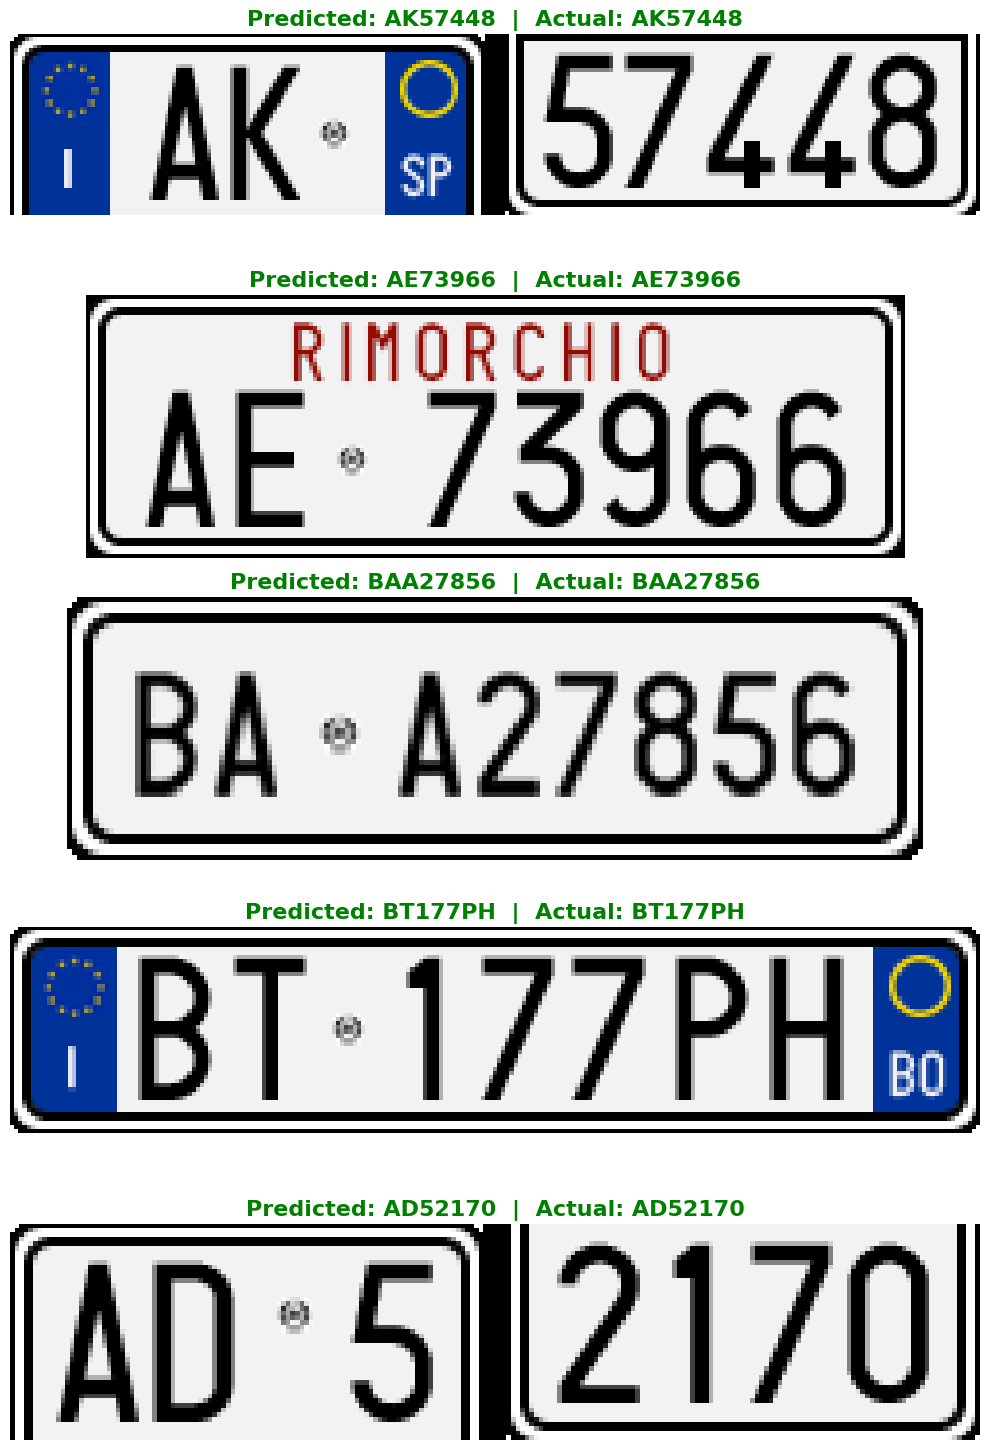

In [10]:
# Testing the model on some random images from data set

import matplotlib.pyplot as plt
import random
import torch
import cv2

print("Loading best model weights...")
# 1. Load the absolute best weights we just saved
weights_path = "/content/drive/MyDrive/CRNN_OCR_UPDATE/ocr/mobilenet_crnn_best.pt"
model.load_state_dict(torch.load(weights_path))
model.eval()

# 2. Instantiate our dataset class just to reuse its robust preprocessing functions
test_pipeline = RobustPlateDataset(DATASET_PATH, is_training=False)

# 3. Pick 5 random images from the dataset
random_paths = random.sample(test_pipeline.image_paths, 5)

fig, axes = plt.subplots(5, 1, figsize=(10, 15))
if not isinstance(axes, np.ndarray):
    axes = [axes]

print("Running Inference...")

with torch.no_grad():
    for i, path in enumerate(random_paths):
        # A. Read image
        raw_img = cv2.imread(str(path))
        raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

        # B. Preprocess (Match Training Exactly)
        # 1. Split-and-Stitch 2-row plates
        lin_img = test_pipeline.linearize_2row_plate(raw_img)

        # 2. Resize to 48px height, pad to 320px width
        padded_img, _ = test_pipeline.resize_pad(lin_img)

        # 3. Normalize and convert to Tensor: Shape [1, 3, 48, 320]
        tensor_img = test_pipeline.normalize(image=padded_img)['image'].unsqueeze(0).cuda()

        # C. Inference
        # Run model and decode CTC output
        preds = model(tensor_img)
        pred_text = decode(preds)[0]

        # D. Get ground truth (Using regex parser)
        gt_text = test_pipeline.parse_label(path.name)

        # E. Visualize
        axes[i].imshow(lin_img) # Show the linearized version so we can see what the CNN sees

        # Color text Green if perfectly correct, Red if there's an error
        title_color = "green" if pred_text == gt_text else "red"
        axes[i].set_title(f"Predicted: {pred_text}  |  Actual: {gt_text}",
                          color=title_color, fontsize=16, fontweight='bold')
        axes[i].axis('off')

plt.tight_layout()
plt.show()

In [11]:
!pip install -q onnx onnxruntime onnxsim onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 19.8 MB/s eta 0:00:00


In [12]:
# ONNX Export (Optimized for Myriad X / OpenVINO)

import torch
import onnx
import onnxsim
import os

weights_path = "/content/drive/MyDrive/CRNN_OCR_UPDATE/ocr/mobilenet_crnn_best.pt"
model.load_state_dict(torch.load(weights_path))
model.eval() # Disables Dropout and freezes BatchNorm

# 2. Define the exact input shape OAK-D will send (Batch=1 for Edge inference)
dummy_input = torch.randn(1, 3, 48, 320).cuda()
onnx_path = "/content/drive/MyDrive/CRNN_OCR_UPDATE/ocr/ocr_mobilenet_v3.onnx"
simplified_onnx_path = "/content/drive/MyDrive/CRNN_OCR_UPDATE/ocr/ocr_mobilenet_v3_sim.onnx"

print("Exporting raw ONNX graph...")
torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=12,           # Opset 12 is highly stable for OpenVINO/LSTM conversion
    do_constant_folding=True,   # Optimizes constant operations
    input_names=['input'],
    output_names=['output']
    # dynamic_axes removed for strict VPU memory allocation
)

print(f"Raw ONNX saved: {onnx_path}")

# 3. Simplify the Graph for Edge Devices
print("Running ONNX Simplifier to strip redundant PyTorch ops...")
model_onnx = onnx.load(onnx_path)
model_simp, check = onnxsim.simplify(model_onnx)

if check:
    onnx.save(model_simp, simplified_onnx_path)
    print(f"Simplified ONNX saved successfully at: {simplified_onnx_path}")

    # Print the expected input/output shapes to verify
    print("\n--- Edge Deployment Specs ---")
    print("Input Node Name : 'input'")
    print("Input Shape     : [1, 3, 48, 320]")
    print("Output Node Name: 'output'")
    print("Output Shape    : [20, 1, 37]  (TimeSteps, Batch, NumClasses)")
else:
    print("Warning: ONNX Simplifier failed verification. You may need to use the raw ONNX file.")

Exporting raw ONNX graph...


W0326 18:58:59.444000 791 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0326 18:59:00.203000 791 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0326 18:59:00.204000 791 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, 

[torch.onnx] Obtain model graph for `MobileNetCRNN([...]` with `torch.export.export(..., strict=False)`...


/usr/lib/python3.12/contextlib.py:158: UserWarning: The tensor attributes self.rnn._flat_weights[0], self.rnn._flat_weights[1], self.rnn._flat_weights[2], self.rnn._flat_weights[3], self.rnn._flat_weights[4], self.rnn._flat_weights[5], self.rnn._flat_weights[6], self.rnn._flat_weights[7], self.rnn._flat_weights[8], self.rnn._flat_weights[9], self.rnn._flat_weights[10], self.rnn._flat_weights[11], self.rnn._flat_weights[12], self.rnn._flat_weights[13], self.rnn._flat_weights[14], self.rnn._flat_weights[15] were assigned during export. Such attributes must be registered as buffers using the `register_buffer` API (https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_buffer).
  self.gen.throw(value)


[torch.onnx] Obtain model graph for `MobileNetCRNN([...]` with `torch.export.export(..., strict=False)`... ❌
[torch.onnx] Obtain model graph for `MobileNetCRNN([...]` with `torch.export.export(..., strict=True)`...
[torch.onnx] Obtain model graph for `MobileNetCRNN([...]` with `torch.export.export(..., strict=True)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

[torch.onnx] Translate the graph into ONNX... ✅
Applied 69 of general pattern rewrite rules.
Raw ONNX saved: /content/drive/MyDrive/CRNN_OCR_UPDATE/ocr/ocr_mobilenet_v3.onnx
Running ONNX Simplifier to strip redundant PyTorch ops...
Simplified ONNX saved successfully at: /content/drive/MyDrive/CRNN_OCR_UPDATE/ocr/ocr_mobilenet_v3_sim.onnx

--- Edge Deployment Specs ---
Input Node Name : 'input'
Input Shape     : [1, 3, 48, 320]
Output Node Name: 'output'
Output Shape    : [20, 1, 37]  (TimeSteps, Batch, NumClasses)
